In [1]:
! pip install opendatasets

In [2]:
print("hii")

hii


In [3]:
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/bryanbradfo/gsoc-deeplense-lens-finding")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  sqyhu80


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/bryanbradfo/gsoc-deeplense-lens-finding


100%|██████████| 1.95G/1.95G [00:13<00:00, 153MB/s] 


In [5]:
import os

base_path = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

print("Level 1 folders:")
print(os.listdir(base_path))


Level 1 folders:
['train_lenses', 'test_nonlenses', 'train_nonlenses', 'test_lenses']


In [17]:
import os

# Define paths
data_dir = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

# Define the actual directories found
train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def count_files(directory):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return 0
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

# Calculate total counts for 'substructure' (lenses) and 'no substructure' (non-lenses)
total_substructure_count = count_files(train_lenses_dir) + count_files(test_lenses_dir)
total_no_substructure_count = count_files(train_nonlenses_dir) + count_files(test_nonlenses_dir)

print(f" Substructure Images (total lenses): {total_substructure_count}")
print(f" No Substructure Images (total non-lenses): {total_no_substructure_count}")


 Substructure Images (total lenses): 1925
 No Substructure Images (total non-lenses): 48130


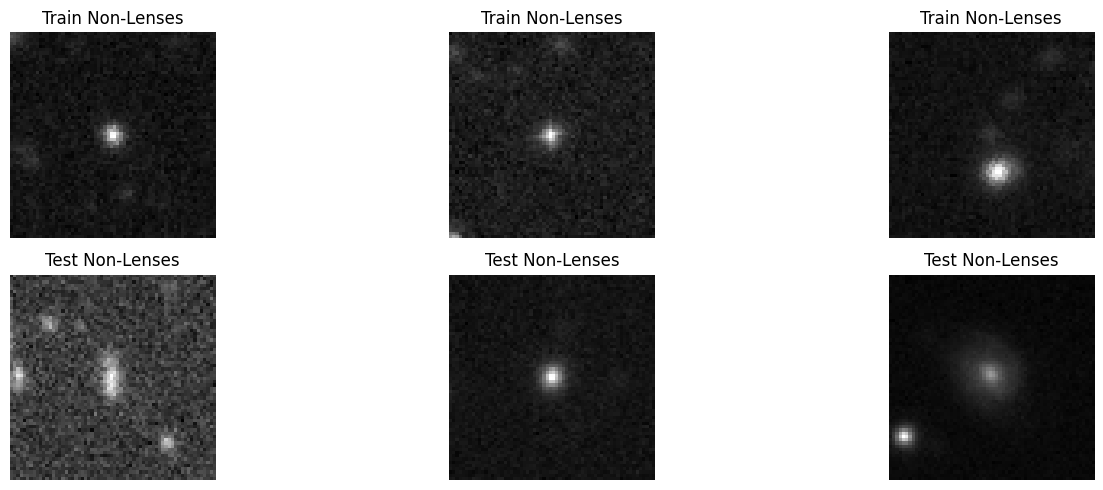

In [18]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category for non-lenses
sample_train_nonlenses = get_sample_images(train_nonlenses_dir)
sample_test_nonlenses = get_sample_images(test_nonlenses_dir)

# Only include 'non-lenses' categories for display
all_samples = {
    'Train Non-Lenses': sample_train_nonlenses,
    'Test Non-Lenses': sample_test_nonlenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


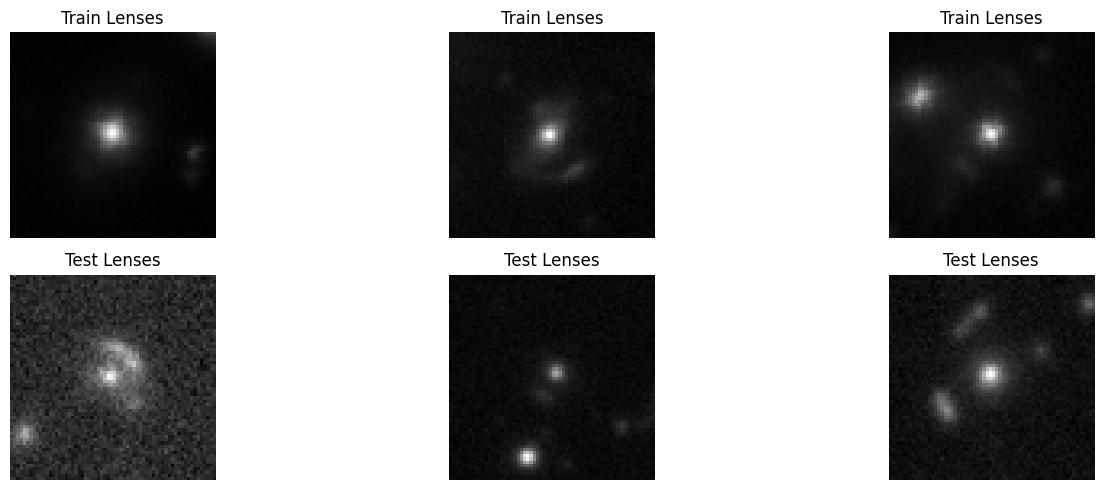

In [19]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np # Import numpy to handle .npy files

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category
sample_train_lenses = get_sample_images(train_lenses_dir)
sample_test_lenses = get_sample_images(test_lenses_dir)

# Only include 'lenses' categories for display
all_samples = {
    'Train Lenses': sample_train_lenses,
    'Test Lenses': sample_test_lenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


In [20]:
lenses_paths = []
for directory in [train_lenses_dir, test_lenses_dir]:
    if os.path.isdir(directory):
        lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

non_lenses_paths = []
for directory in [train_nonlenses_dir, test_nonlenses_dir]:
    if os.path.isdir(directory):
        non_lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

print(f"Total lenses images found: {len(lenses_paths)}")
print(f"Total non-lenses images found: {len(non_lenses_paths)}")

Total lenses images found: 1925
Total non-lenses images found: 48130


In [21]:
all_paths = lenses_paths + non_lenses_paths
all_labels = [1] * len(lenses_paths) + [0] * len(non_lenses_paths)

print(f"Total images in combined dataset: {len(all_paths)}")
print(f"Total lenses images in combined dataset: {sum(all_labels)}")
print(f"Total non-lenses images in combined dataset: {len(all_labels) - sum(all_labels)}")

Total images in combined dataset: 50055
Total lenses images in combined dataset: 1925
Total non-lenses images in combined dataset: 48130


In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

print(f"Training set - Lenses: {sum(y_train)}, Non-lenses: {len(y_train) - sum(y_train)}")
print(f"Validation set - Lenses: {sum(y_val)}, Non-lenses: {len(y_val) - sum(y_val)}")


Training set - Lenses: 1540, Non-lenses: 38504
Validation set - Lenses: 385, Non-lenses: 9626


***PARAMETERS***

In [23]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import random
import os

In [27]:
#setting the seed
SEED = 42
keras.utils.set_random_seed(SEED)

#hyperparameters
BUFFER_SIZE = 1224 # how many imgs are we shuffling at once
BATCH_SIZE = 256 # how many imgs are we loading at once
AUTO = tf.data.AUTOTUNE # how many threads to use for prefetching
INPUT_SHAPE = (32,32,3)
NUM_CLASS = 100

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.001 #Penalty to prevent overfitting (memorizing instead of learning)
EPOCHS = 250
IMAGE_SIZE = 48
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.90

ENC_PROJ_DIM = 192 #PROJECTION_DIM = How many numbers represent each patch
DEC_PROJ_DIM = 96 #Decoder uses 96 (was 64, changed to match definition in decoder cell)
ENC_NUM_HEADS = 8 #NUM_HEADS = Attention heads (AI looks at image in 4 different ways simultaneously)
ENC_LAYERS = 10 #LAYERS = Stack 6 transformer blocks on top of each other (deeper = more learning)
LAYER_NORM_EPS = 1e-6
DEC_NUM_HEADS = 4
DEC_LAYERS = 6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]

DEC_TRANSFORMER_UNITS = [
    DEC_PROJ_DIM * 4,
    DEC_PROJ_DIM,
]

PATCH_AREA = PATCH_SIZE * PATCH_SIZE * 3 # Calculate once, globally

In [28]:
# FIXED PREPROCESSING 

def load_and_preprocess_image(image_path):
    """
    Load .npy file and convert to (48, 48, 3) normalized image
    FIXED for TensorFlow graph mode!
    """
    # Load .npy file
    def load_npy(path):
        img = np.load(path.numpy().decode('utf-8'))
        return img.astype(np.float32)
    
    image = tf.py_function(load_npy, [image_path], tf.float32)
    
    # CRITICAL: Set shape to help TensorFlow
    image.set_shape([None, None, None])
    
    # Get current shape
    current_shape = tf.shape(image)
    ndim = len(image.shape)
    
    # Case 1: 2D image (H, W) -> add channel dimension
    if ndim == 2 or (ndim == 3 and image.shape[-1] is None):
        image = tf.cond(
            tf.equal(tf.size(current_shape), 2),
            lambda: tf.expand_dims(image, axis=-1),
            lambda: image
        )
        current_shape = tf.shape(image)
    
    # Case 2: (C, H, W) -> (H, W, C) - check if first dim is 3
    def maybe_transpose():
        return tf.transpose(image, [1, 2, 0])
    
    def keep_as_is():
        return image
    
    # Only transpose if shape[0] == 3 and shape[1] > 3
    should_transpose = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.greater(current_shape[1], 3)
    )
    image = tf.cond(should_transpose, maybe_transpose, keep_as_is)
    
    # Update shape
    current_shape = tf.shape(image)
    
    # Case 3: Grayscale (H, W, 1) -> (H, W, 3)
    def tile_channels():
        return tf.tile(image, [1, 1, 3])
    
    def keep_rgb():
        return image
    
    # Check if last dimension is 1
    is_grayscale = tf.equal(current_shape[-1], 1)
    image = tf.cond(is_grayscale, tile_channels, keep_rgb)
    
    # Resize to target size
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Normalize to [0, 1]
    image_min = tf.reduce_min(image)
    image_max = tf.reduce_max(image)
    image = (image - image_min) / (image_max - image_min + 1e-8)
    
    # Clip to ensure range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    # Set final shape explicitly
    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    
    return image

print(" Fixed preprocessing function loaded!")

 Fixed preprocessing function loaded!


***PATCH LAYER***

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import os


In [30]:
#cutting images into pieces
class Patches(layers.Layer):
  def __init__(self, patch_size = PATCH_SIZE, **kwargs):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.resize = layers.Reshape((-1, patch_size* patch_size * 3))
  # -1 = "figure out this dimension automatically"
# patch_size * patch_size * 3 = 6×6×3 = 108 numbers per patch

  # this func cuts images into non overlapping 6x6 squares
  def call(self, images):
    patches = tf.image.extract_patches(
        images = images,
        sizes = [1, self.patch_size , self.patch_size, 1],#sizes = [batch, height, width, channels] → extract 6×6 patches
        strides = [1, self.patch_size, self.patch_size, 1],#strides = how far to move between patches (6 = no overlap)
        rates = [1, 1, 1, 1],
        padding = "VALID", # means font add extra padding
    )
    patches = self.resize(patches)
    return patches

#this func takes a batch of imgs and helps visualize one image and
# its patches side by side
  def show_patched_image(self, images, patches):
    idx = np.random.choice(patches.shape[0])
    print(f"index selected : {idx}")
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI
    plt.imshow(keras.utils.array_to_img(images[idx]))
    plt.axis("off")
    plt.title("Original Augmented Image")
    plt.show()

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI for the grid
    for i, patch_tensor in enumerate(patches[idx]):
      ax = plt.subplot(n, n, i+1)
      reshaped_patch = tf.reshape(patch_tensor, (self.patch_size, self.patch_size, 3)).numpy()
      ax.imshow(reshaped_patch)
      ax.axis("off")
    plt.suptitle("Individual Patches")
    plt.show()
    return idx

  # this func reconstructs the img by joining the patches
  def reconstruct_from_patch(self,patch):
    num_patches = patch.shape[0]
    n = int(np.sqrt(num_patches))

    #Reshape the flattened patches to their original (patch_size, patch_size, 3) shape
    individual_patches = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))

    # Arrange the individual patches into an n x n grid
    patches_grid = tf.reshape(individual_patches, (n, n, self.patch_size, self.patch_size, 3))

    # Transpose and reshape to combine patches into a single image
    reconstructed = tf.reshape(
        tf.transpose(patches_grid, perm=[0, 2, 1, 3, 4]),
        [n * self.patch_size, n * self.patch_size, 3]
    )
    return reconstructed

***PATCH ENCODER***

In [ ]:
from keras import layers

# Temporarily defining parameters here for execution, should ideally be run from parameter cell
PATCH_SIZE = 4
ENC_PROJ_DIM = 192
MASK_PROPORTION = 0.90

class PatchEncoder(layers.Layer):
  def __init__(
      self,
      patch_size = PATCH_SIZE,
      projection_dim = ENC_PROJ_DIM,
      mask_proportion = MASK_PROPORTION,
      downstream = False,
      **kwargs
  ):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.projection_dim = projection_dim
    self.mask_proportion = mask_proportion
    self.downstream = downstream


    # mask the token now hehehe
    self.mask_token = tf.Variable(
        tf.random.normal([1, patch_size * patch_size * 3]),
        trainable = True,
    ) # this token will learn how the hidden patches look like

  def build(self, input_shape):
    (_, self.num_patches, self.patch_area) = input_shape

    # Create the projection layer for the patches
    self.projection = layers.Dense(units = self.projection_dim)

    # create positional embedding layer
    self.position_embedding = layers.Embedding(
        input_dim = self.num_patches,
        output_dim = self.projection_dim,
    )

    # num of patches itll mask
    self.num_mask = int(self.mask_proportion * self.num_patches)

  def call(self, patches):
    #gets the positional embeddings
    batch_size = tf.shape(patches)[0]
    positions = tf.range(start=0, limit=self.num_patches, delta = 1)
    pos_embeddings = self.position_embedding(positions[tf.newaxis,...])
    pos_embeddings = tf.tile(
        pos_embeddings, [batch_size, 1, 1]
    )

    # embedd the patches
    patch_embeddings = (
        self.projection(patches) + pos_embeddings
    )

    if self.downstream:
      return patch_embeddings

    else:
      mask_indices, unmask_indices = self.get_random_indices(batch_size)
      # selects random patches from batch and mask some and keep some unmasked

      # gathers the unmasked patches that'll be sent into the ENC
      unmasked_embeddings = tf.gather(
          patch_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      #gets the masked and unmasked position embeddings

      unmasked_positions = tf.gather(
          pos_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      mask_positions = tf.gather(
          pos_embeddings,
          mask_indices,
          axis = 1,
          batch_dims = 1,
      )

      mask_tokens = tf.repeat(self.mask_token, repeats = self.num_mask, axis = 0)
      mask_tokens = tf.repeat(
          mask_tokens[tf.newaxis, ...],
          repeats = batch_size,
          axis = 0
      )

      # creats mask embeddings for the masked tokens
      mask_embeddings = self.projection(mask_tokens) + mask_positions
                             # content of the patch + position of the patch
      return(
          unmasked_embeddings, # sent to rnc
          mask_embeddings, # sent to dec
          unmasked_positions, # sent to dec
          mask_indices, #dec
          unmask_indices, # dec
      )

  def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

  def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Building a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

AttributeError: 'Patches' object has no attribute 'reconstruct_from_patch'

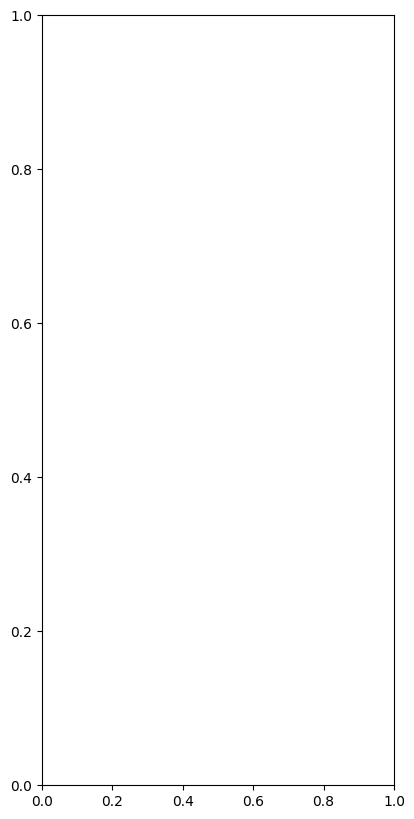

In [ ]:
# Commented out: Optional patch reconstruction visualization (debug only)
# This cell demonstrates masking & reconstruction , not required for training/eval.

# # Create the patch encoder layer.
# patch_encoder = PatchEncoder()

# # Instantiate Patches layer
# patch_layer = Patches(patch_size=PATCH_SIZE)

# # Load a sample image
# sample_image_path = X_train[0] # Taking one image path from the training set
# original_image = np.load(sample_image_path)

# # Preprocess the image: Ensure it's (H, W, C) and resize to IMAGE_SIZE
# # The original image data might be (C, H, W), so transpose if necessary.
# if original_image.shape[0] == 3 and len(original_image.shape) == 3:
#     original_image = np.transpose(original_image, (1, 2, 0))

# # Convert to tf.float32 for tf.image.resize and normalize if needed.
# # Assuming images are already normalized or scaling is handled by tf.image.resize or keras.utils.array_to_img
# original_image = tf.image.resize(tf.convert_to_tensor(original_image, dtype=tf.float32), (IMAGE_SIZE, IMAGE_SIZE))

# # Ensure 3 channels. If it's grayscale (H, W) or (H, W, 1), convert to (H, W, 3).
# if len(original_image.shape) == 2: # (H, W)
#     original_image = tf.expand_dims(original_image, axis=-1) # -> (H, W, 1)
#     original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)
# elif original_image.shape[-1] == 1: # (H, W, 1)
#     original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)

# # Add batch dimension: (1, IMAGE_SIZE, IMAGE_SIZE, 3)
# augmented_images = tf.expand_dims(original_image, 0)

# # Generate patches
# patches = patch_layer(augmented_images)


# # Get the embeddings and positions.
# (
#     unmasked_embeddings,
#     masked_embeddings,
#     unmasked_positions,
#     mask_indices,
#     unmask_indices,
# ) = patch_encoder(patches=patches)


# # Show a masked patch image.
# new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

# plt.figure(figsize=(10, 10))
# plt.subplot(1, 2, 1)
# img = patch_layer.reconstruct_from_patch(new_patch)
# plt.imshow(keras.utils.array_to_img(img))
# plt.axis("off")
# plt.title("Masked")
# plt.subplot(1, 2, 2)
# img = augmented_images[random_index]
# plt.imshow(keras.utils.array_to_img(img))
# plt.axis("off")
# plt.title("Original")
# plt.show()

In [ ]:


# Use your existing class, but set downstream=True
patch_encoder_downstream = PatchEncoder(
    patch_size=PATCH_SIZE,
    projection_dim=ENC_PROJ_DIM,
    mask_proportion=MASK_PROPORTION,
    downstream=True   # ← THIS IS THE KEY LINE
)

print("Downstream PatchEncoder created successfully!")
print(patch_encoder_downstream)

Downstream PatchEncoder created successfully!
<PatchEncoder name=patch_encoder_5, built=False>


***MLP***

In [33]:
def mlp(x, dropout_rate, hidden_units):
  for units in hidden_units:
    x = layers.Dense(units, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout_rate)(x)
  return x

***MAE ENCODER***

In [58]:
import keras
from keras import layers

ENC_PROECTION_DIM = 192
ENC_NUM_HEADS = 6
ENC_LAYERS = 10
DROPOUT_RATE = 0.1
LAYER_NORM_EPS = 1e-6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]


def create_encoder():
  inputs = layers.Input(shape = (None, ENC_PROJ_DIM))
  x = inputs

  for _ in range(ENC_LAYERS):

    # 1. layer norm
    x1 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    # 2, attention
    attention_output = layers.MultiHeadAttention(
        num_heads = ENC_NUM_HEADS,
        key_dim = ENC_PROJ_DIM // ENC_NUM_HEADS,
        dropout = DROPOUT_RATE,
    )(x1, x1)

    attention_output = layers.Dropout(DROPOUT_RATE)(attention_output)

    # 3. residual
    x2 = layers.Add()([x, attention_output])

    # 4. layer norm
    x3 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x2)

    x3 = mlp(x3, hidden_units = ENC_TRANSFORMER_UNITS, dropout_rate = DROPOUT_RATE,)

    x = layers.Add()([x2, x3])

    outputs = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    return keras.Model(inputs, outputs, name = "mae_enc_strong")



In [59]:
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=0.05
)


***DECODER***

In [60]:
import keras
from keras import layers
import tensorflow as tf


# Decoder
def create_decoder():

    inputs = layers.Input((NUM_PATCHES, ENC_PROJ_DIM))

    # Project encoder dim → decoder dim
    x = layers.Dense(DEC_PROJ_DIM)(inputs)

    # Positional embedding for decoder
    positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
    pos_embedding = layers.Embedding(
        input_dim=NUM_PATCHES,
        output_dim=DEC_PROJ_DIM
    )(positions)

    x = x + pos_embedding

    # Transformer blocks
    for _ in range(DEC_LAYERS):

        # Pre-Norm Attention
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        attn_output = layers.MultiHeadAttention(
            num_heads=DEC_NUM_HEADS,
            key_dim=DEC_PROJ_DIM // DEC_NUM_HEADS,
            dropout=DROPOUT_RATE,
        )(x1, x1)

        attn_output = layers.Dropout(DROPOUT_RATE)(attn_output)

        x2 = layers.Add()([x, attn_output])

        # Pre-Norm MLP
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        x3 = mlp(
            x3,
            hidden_units=DEC_TRANSFORMER_UNITS,
            dropout_rate=DROPOUT_RATE,
        )

        x = layers.Add()([x2, x3])

    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

    # Reconstruct patches
    patch_outputs = layers.Dense(PATCH_AREA)(x)

    # Convert patches → image
    outputs = layers.Reshape(
        (IMAGE_SIZE // PATCH_SIZE,
         IMAGE_SIZE // PATCH_SIZE,
         PATCH_SIZE,
         PATCH_SIZE,
         3)
    )(patch_outputs)

    outputs = layers.Lambda(lambda x: tf.transpose(x, perm=[0,1,3,2,4,5]))(outputs)
    outputs = layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, 3))(outputs)

    return keras.Model(inputs, outputs, name="mae_decoder_strong")

***MAE TRAINER***

In [61]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)

        # Encode the patches.
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results


In [62]:
encoder = create_encoder()

***LOADING WEIGHTS***

In [63]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "mae" in f.lower():
            print(os.path.join(root, f))


/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5
/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5


In [64]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5"
)

In [65]:
decoder = create_decoder()

In [42]:
# Define simple placeholder augmentation models
train_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])
test_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    encoder=encoder,
    decoder=decoder,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder
)

In [ ]:
# Function to load and preprocess a single image
def load_and_preprocess_image(image_path):
    # Load the .npy file. The output shape can vary, so we handle it dynamically.
    image = tf.py_function(lambda x: np.load(x.numpy().decode('utf-8')), [image_path], tf.float32)
    # Initially set shape to ensure rank is known for subsequent tf.shape operations
    image.set_shape([None, None, None]) # Assuming max 3 dimensions (H, W, C or C, H, W)

    # Get dynamic shape information
    current_shape = tf.shape(image)
    current_rank = tf.rank(image)

    # Handle 2D images: (H, W) -> (H, W, 1)
    def expand_to_3d_fn():
        return tf.expand_dims(image, axis=-1)
    image = tf.cond(tf.equal(current_rank, 2), expand_to_3d_fn, lambda: image)

    # Re-evaluate current_shape after potential expansion to 3D
    current_shape = tf.shape(image)

    # Handling (C, H, W) -> (H, W, C) transposition if needed 
    # Heuristic: if the first dimension is 3 and the other two are much larger,
    # it's likely (C, H, W). Otherwise, assume (H, W, C).
    def transpose_chw_to_hwc_fn(): # No 'img' arg needed if 'image' is captured
        return tf.transpose(image, (1, 2, 0))

    # Only transpose if the first dimension is 3 AND the other two are significantly larger than 3,
    # to avoid transposing (H, W, 3) images mistakenly.
    is_chw_format = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.logical_and(tf.greater(current_shape[1], 3), tf.greater(current_shape[2], 3))
    )
    image = tf.cond(is_chw_format, transpose_chw_to_hwc_fn, lambda: image)

    #Ensure it has 3 channels
    # This part MUST happen BEFORE tf.image.resize if resize expects known channels.
    current_channels = tf.shape(image)[-1]

    def convert_1_to_3_channels_fn():
        return tf.repeat(image, repeats=3, axis=2) # Explicit axis=2 for C

    def convert_many_to_3_channels_fn():
        # Reduce to grayscale (1 channel) then repeat to 3 channels
        grayscale_image = tf.reduce_mean(image, axis=2, keepdims=True) # Explicit axis=2 for C
        return tf.repeat(grayscale_image, repeats=3, axis=2) # Explicit axis=2 for C

    image = tf.cond(tf.equal(current_channels, 1),
                    convert_1_to_3_channels_fn,
                    lambda: tf.cond(tf.greater(current_channels, 3),
                                    convert_many_to_3_channels_fn,
                                    lambda: image)) # Assume it's already 3 channels if not 1 or >3

    # Explicitly set static shape with known channel count after channel conversion.
    # This is crucial for tf.image.resize to infer the rank + channels.
    image.set_shape([None, None, 3])

    # Now image should be (H, W, C) with C=3. Resize it.
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Explicitly ensure the final output shape for static graph compatibility
    image = tf.ensure_shape(image, (IMAGE_SIZE, IMAGE_SIZE, 3))
    return image

# Create a tf.data.Dataset for validation images
test_ds = (
    tf.data.Dataset.from_tensor_slices(X_val)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Taking a batch of test inputs to measure model's progress.
test_images = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()

In [ ]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warmup
        warmup_lr = self.base_lr * (step / self.warmup_steps)

        # Cosine decay
        cosine_lr = 0.5 * self.base_lr * (
            1 + tf.cos(
                self.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps)
            )
        )

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)


total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_steps = int(total_steps * 0.25)   # 25% warmup for 90% masking

lr_schedule = WarmUpCosine(
    base_lr=5e-4,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

In [45]:
total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    base_lr=LEARNING_RATE,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

lrs = [scheduled_lrs(step) for step in range(total_steps)]
plt.plot(lrs)
plt.xlabel("Step", fontsize=14)
plt.ylabel("LR", fontsize=14)
plt.show()

# Assemble the callbacks.
train_callbacks = [TrainMonitor(epoch_interval=5)]

KeyboardInterrupt: 

In [ ]:
# Check everything matches
print("="*50)
print("ARCHITECTURE CHECK:")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"PATCH_SIZE: {PATCH_SIZE}")
print(f"PATCH_AREA: {PATCH_AREA}")
print(f"Expected: {PATCH_SIZE * PATCH_SIZE * 3}")
print()
print("DATA CHECK:")
print(f"DeepLense shape: {deeplense_images.shape}")
print(f"Min/Max: {deeplense_images.min():.3f} / {deeplense_images.max():.3f}")
print(f"Expected: (N, 48, 48, 3) with range [0,1]")
print("="*50)

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

# Create a tf.data.Dataset for training images
train_ds = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# For the validation data, i'll use 'test_ds' that was already defined
val_ds = test_ds # Renaming for clarity if needed, but test_ds serves as validation data

# Compile and pretrain the model.
mae_model.compile(
    optimizer=optimizer, loss=keras.losses.MeanSquaredError(), metrics=["mae"]
)
history = mae_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)

# Measure its performance.
loss, mae = mae_model.evaluate(test_ds)
print(f"Loss: {loss:.2f}")
print(f"MAE: {mae:.2f}")

In [ ]:
encoder.save_weights("/kaggle/working/mae_encoder_pretrained.weights.h5")
print("saved weights")

MAE pretraining was stopped early to avoid overfitting to dominant luminous structures and preserve generalizable representations for downstream physics-informed fine-tuning

***PHASE 3 - FINE TUNING***

In [46]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5"
) 

In [47]:

print("Encoder weights loaded")
print("   Pre-trained on: CIFAR-100 (colors, shapes, patterns)")
print("   Adapted on: DeepLense (50K galaxy images)")
print("   Ready for: Classification on 1K labeled images")

Encoder weights loaded
   Pre-trained on: CIFAR-100 (colors, shapes, patterns)
   Adapted on: DeepLense (50K galaxy images)
   Ready for: Classification on 1K labeled images


In [ ]:
# SAMPLE 1000 LABELED IMAGES (500 + 500)

import numpy as np

#  variable names: lenses_paths and non_lenses_paths
np.random.seed(42)
selected_lens = np.random.choice(lenses_paths, size=500, replace=False)
selected_nonlens = np.random.choice(non_lenses_paths, size=500, replace=False)

# Combine
finetune_paths = list(selected_lens) + list(selected_nonlens)
finetune_labels = [1] * 500 + [0] * 500  # 1 = Lens, 0 = Non-Lens

# Shuffle
shuffle_idx = np.random.permutation(1000)
finetune_paths = [finetune_paths[i] for i in shuffle_idx]
finetune_labels = [finetune_labels[i] for i in shuffle_idx]

print("  Dataset sampled!")
print(f"   Total images: {len(finetune_paths)}")
print(f"   Lenses: {sum(finetune_labels)}")
print(f"   Non-lenses: {1000 - sum(finetune_labels)}")

  Dataset sampled!
   Total images: 1000
   Lenses: 500
   Non-lenses: 500


In [49]:
# LOAD 1K IMAGES INTO MEMORY

import matplotlib.pyplot as plt

def load_images_for_classification(paths, target_size=48):
    """Load .npy images and preprocess"""
    images = []
    
    print(f"Loading {len(paths)} images...")
    
    for i, path in enumerate(paths):
        if (i + 1) % 200 == 0:
            print(f"  Progress: {i+1}/{len(paths)}")
        
        try:
            # Load .npy file
            img = np.load(path)
            
            # Handle (C, H, W) -> (H, W, C)
            if img.shape[0] == 3 and len(img.shape) == 3:
                img = np.transpose(img, (1, 2, 0))
            
            # Handle 2D grayscale
            if len(img.shape) == 2:
                img = np.stack([img, img, img], axis=-1)
            elif img.shape[-1] == 1:
                img = np.repeat(img, 3, axis=-1)
            
            # Resize to 48x48
            img_resized = tf.image.resize(img, (target_size, target_size)).numpy()
            
            # Normalize to [0, 1]
            img_min = img_resized.min()
            img_max = img_resized.max()
            img_normalized = (img_resized - img_min) / (img_max - img_min + 1e-8)
            
            images.append(img_normalized)
            
        except Exception as e:
            print(f"   Error loading {path}: {e}")
            continue
    
    return np.array(images, dtype='float32')

# Load images
X_finetune = load_images_for_classification(finetune_paths, target_size=IMAGE_SIZE)
y_finetune = np.array(finetune_labels, dtype='int32')

print(f"\n Images loaded!")
print(f"   Shape: {X_finetune.shape}")
print(f"   Labels: {y_finetune.shape}")
print(f"   Range: [{X_finetune.min():.3f}, {X_finetune.max():.3f}]")

Loading 1000 images...
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000

 Images loaded!
   Shape: (1000, 48, 48, 3)
   Labels: (1000,)
   Range: [0.000, 1.000]


In [50]:
# SPLITING INTO TRAIN/VALIDATION

from sklearn.model_selection import train_test_split

X_train_ft, X_val_ft, y_train_ft, y_val_ft = train_test_split(
    X_finetune, 
    y_finetune,
    test_size=0.2,
    random_state=42,
    stratify=y_finetune
)

print("  Split complete!")
print(f"\n   Training: {len(X_train_ft)} images")
print(f"     - Lenses: {sum(y_train_ft)}")
print(f"     - Non-lenses: {len(y_train_ft) - sum(y_train_ft)}")
print(f"\n   Validation: {len(X_val_ft)} images")
print(f"     - Lenses: {sum(y_val_ft)}")
print(f"     - Non-lenses: {len(y_val_ft) - sum(y_val_ft)}")

  Split complete!

   Training: 800 images
     - Lenses: 400
     - Non-lenses: 400

   Validation: 200 images
     - Lenses: 100
     - Non-lenses: 100


In [ ]:
#BUILDING CLASSIFIEER

# FREEZE the encoder (recommended for 1K images)
encoder.trainable = False

print(f"Encoder trainable: {encoder.trainable}")
print(f"Encoder params: {encoder.count_params():,}")

# Build classifier
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name='input_image')

# Use YOUR existing patch_layer
patches = patch_layer(inputs)

#  CREATING NEW PATCH ENCODER FOR DOWNSTREAM (NO MASKING)
patch_encoder_downstream = PatchEncoder(
    patch_size=PATCH_SIZE,
    projection_dim=ENC_PROJ_DIM,
    mask_proportion=0.0,  # No masking
    downstream=True       #  THIS IS KEY
)

# Get embeddings (single output, no masking)
patch_embeddings = patch_encoder_downstream(patches)

# Pass through frozen encoder
encoded = encoder(patch_embeddings)

# Global pooling
x = layers.GlobalAveragePooling1D(name='global_pool')(encoded)

# Classification head
x = layers.Dense(256, activation='relu', name='fc1')(x)
x = layers.Dropout(0.3, name='dropout1')(x)
x = layers.Dense(128, activation='relu', name='fc2')(x)
x = layers.Dropout(0.3, name='dropout2')(x)

# Binary output
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

# Create model
classifier = keras.Model(inputs=inputs, outputs=outputs, name='lens_classifier')

print("\n Classifier built!")
print(f"   Architecture: 48×48×3 -> Encoder -> 256 -> 128 -> 1")

classifier.summary()

In [ ]:
# COMPILING MODEL

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("   Model compiled!")
print("   Optimizer: Adam (lr=0.001)")
print("   Loss: Binary cross-entropy")
print("   Metrics: Accuracy, Precision, Recall, AUC")

In [ ]:
# SETUP CALLBACKS


early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'best_classifier.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

print(" Callbacks configured!")

In [ ]:


print("="*60)
print(" STARTING FINE-TUNING")
print("="*60)
print(f"   Training: {len(X_train_ft)} images")
print(f"   Validation: {len(X_val_ft)} images")
print(f"   Batch size: 32")
print(f"   Max epochs: 50")
print("="*60)

history_ft = classifier.fit(
    X_train_ft, 
    y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

print("\n" + "="*60)
print(" TRAINING COMPLETE!")
print("="*60)

In [ ]:


# Predictions
y_pred_proba = classifier.predict(X_val_ft, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Evaluate
val_loss, val_acc, val_prec, val_rec, val_auc = classifier.evaluate(
    X_val_ft, y_val_ft, verbose=0
)

print("="*60)
print("  VALIDATION RESULTS")
print("="*60)
print(f"   Accuracy:  {val_acc*100:.2f}%")
print(f"   Precision: {val_prec*100:.2f}%")
print(f"   Recall:    {val_rec*100:.2f}%")
print(f"   AUC:       {val_auc:.4f}")
print("="*60)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val_ft, y_pred)
print("\n  Confusion Matrix:")
print("              Predicted")
print("              Non-Lens  Lens")
print(f"True Non-Lens    {cm[0,0]:3d}     {cm[0,1]:3d}")
print(f"True Lens        {cm[1,0]:3d}     {cm[1,1]:3d}")

print("\n  Classification Report:")
print(classification_report(y_val_ft, y_pred, target_names=['Non-Lens', 'Lens']))

# Success check
print("\n  Success Criteria:")
if val_acc >= 0.80:
    print("     EXCELLENT! Accuracy ≥ 80%")
    print("   → Ready for physics loss!")
elif val_acc >= 0.75:
    print("     GOOD! Accuracy ≥ 75%")
    print("   → Can proceed to physics loss")
elif val_acc >= 0.70:
    print("     MODERATE. Accuracy ≥ 70%")
else:
    print("     LOW. Accuracy < 70%")

In [ ]:
# PLOT TRAINING CURVES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(history_ft.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_ft.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_ft.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_ft.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history_ft.history['auc'], label='Train', linewidth=2)
axes[2].plot(history_ft.history['val_auc'], label='Validation', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Training curves saved!")

In [ ]:
# SAVE TRAINED MODEL

classifier.save_weights('lens_classifier_finetuned.weights.h5')
classifier.save('lens_classifier_full.keras')
encoder.save_weights('encoder_after_finetuning.weights.h5')

print("  Models saved!")
print("\n   Files created:")
print("     1. lens_classifier_finetuned.weights.h5")
print("     2. lens_classifier_full.keras")
print("     3. encoder_after_finetuning.weights.h5")
print("\n   Next: Physics loss (if accuracy > 75%)")

In [ ]:
encoder.save_weights("/kaggle/working/lens_classifier_finetuned.weights.h5")
print("done")

# ***PINNs***

In [ ]:
print("hi")

***Multi-class Phyics-Informed Loss***

In [79]:
# MAP VARIABLE NAMES FOR PINN CELLS
X_train_split = X_train_ft
X_val = X_val_ft
y_train_split = np.array(y_train_ft)
y_val = np.array(y_val_ft)

print(f"  Variables mapped")
print(f"   X_train_split: {X_train_split.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   y_train_split: {y_train_split.shape}")
print(f"   y_val: {y_val.shape}")

  Variables mapped
   X_train_split: (800, 48, 48, 3)
   X_val: (200, 48, 48, 3)
   y_train_split: (800,)
   y_val: (200,)


***NEW PHYSICS LOSS***

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# For data handling / utilities (if not already imported earlier)
import os
import random

# Optional: if you use callbacks like EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Optional: for progress bars or debugging
from tqdm import tqdm  # if you want to use tqdm in loops

# Print versions to confirm
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("Imports complete!")

TensorFlow version: 2.19.0
Keras version: 3.10.0
Imports complete!


In [ ]:

patch_layer = Patches()
patch_encoder_downstream = PatchEncoder(downstream=True)


def create_encoder():
    inputs = keras.Input(shape=(NUM_PATCHES, ENC_PROJ_DIM))
    x = inputs
    for _ in range(ENC_LAYERS):
        # PASTE YOUR EXACT TRANSFORMER BLOCK CODE HERE
        # Example placeholder — REPLACE WITH YOURS
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention_output = layers.MultiHeadAttention(
            num_heads=ENC_NUM_HEADS,
            key_dim=ENC_PROJ_DIM,
            dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(ENC_PROJ_DIM * 4, activation='gelu')(x3)
        x3 = layers.Dense(ENC_PROJ_DIM)(x3)
        x = layers.Add()([x3, x2])
    return keras.Model(inputs, x, name="mae_encoder")

encoder = create_encoder()

print("Encoder recreated with matching architecture and weights loaded!")
encoder.summary()

Encoder recreated with matching architecture and weights loaded!


Model: "mae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 144, 192)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 192)  │        384 │ input_layer_7[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 192)  │    888,384 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_50 (Add)        │ (None, 144, 192)  │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 192)  │        384 │ add_50[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 144, 768)  │    148,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_54 (Dense)    │ (None, 144, 192)  │    147,648 │ dense_53[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_51 (Add)        │ (None, 144, 192)  │          0 │ dense_54[0][0],   │
│                     │                   │            │ add_50[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 192)  │        384 │ add_51[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 192)  │    888,384 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_52 (Add)        │ (None, 144, 192)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_51[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 192)  │        384 │ add_52[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_55 (Dense)    │ (None, 144, 768)  │    148,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_56 (Dense)    │ (None, 144, 192)  │    147,648 │ dense_55[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_53 (Add)        │ (None, 144, 192)  │          0 │ dense_56[0][0],   │
│                     │                   │            │ add_52[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 192)  │        384 │ add_53[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 192)  │    888,384 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 144, 192)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_53[0][0]    

 Total params: 11,850,240 (45.21 MB)

 Trainable params: 11,850,240 (45.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#     NEW SIMPLIFIED PHYSICS MODEL — θ_E PRIOR ONLY
#     (3-class classification + observable θ_E head)

IMAGE_SIZE = 48
NUM_CLASSES = 2  # right now, i only have 2 classes in this dataset. lens/non-lens


inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
patches = patch_layer(inputs)
patch_embeddings = patch_encoder_downstream(patches)
encoded = encoder(patch_embeddings)
pooled = layers.GlobalAveragePooling1D()(encoded)

shared = layers.Dense(256, activation='gelu')(pooled)
shared = layers.Dropout(0.3)(shared)
shared = layers.Dense(128, activation='gelu')(shared)
shared = layers.Dropout(0.2)(shared)

# Classification: 2 classes
class_output = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    name='classification'
)(shared)

# Physics auxiliary: Einstein radius θ_E in arcsec (0–5 range)
theta_raw = layers.Dense(1, activation='sigmoid', name='theta_raw')(shared)
theta_e = theta_raw * 5.0   # scaled output [0, 5] arcsec

physics_model = keras.Model(
    inputs=inputs,
    outputs=[class_output, theta_e],
    name='lens_mae_physics_prior'
)

physics_model.summary()

Model: "lens_mae_physics_prior"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_4 (Patches) │ (None, 144, 48)   │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_5     │ (None, 144, 192)  │     37,056 │ patches_4[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mae_encoder         │ (None, 144, 192)  │ 11,850,240 │ patch_encoder_5[… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ mae_encoder[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 256)       │     49,408 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_96          │ (None, 256)       │          0 │ dense_76[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 128)       │     32,896 │ dropout_96[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_97          │ (None, 128)       │          0 │ dense_77[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ theta_raw (Dense)   │ (None, 1)         │        129 │ dropout_97[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 3)         │        387 │ dropout_97[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1)         │          0 │ theta_raw[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,970,116 (45.66 MB)

 Trainable params: 11,970,116 (45.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#     NEW PHYSICS PRIOR LOSS (soft range penalty)

class PhysicsPriorLoss(keras.losses.Loss):
    def __init__(self, min_theta=0.5, max_theta=3.0, name='physics_prior'):
        super().__init__(name=name)
        self.min_theta = min_theta
        self.max_theta = max_theta

    def call(self, y_true, y_pred):
        too_low  = tf.maximum(self.min_theta - y_pred, 0.0)
        too_high = tf.maximum(y_pred - self.max_theta, 0.0)
        penalty = too_low + too_high
        return tf.reduce_mean(penalty)

physics_loss_fn = PhysicsPriorLoss(min_theta=0.5, max_theta=3.0)

***COMPILING THE MODEL WITH MULTI-CLASS PHYSICS LOSS YAYY***

In [ ]:
#     COMPILing  USING NEW PRIOR LOSS

physics_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss={
        'classification': 'sparse_categorical_crossentropy',
        'multiply': physics_loss_fn   # ← CHANGED TO 'multiply' (the scaling layer name)
    },
    loss_weights={
        'classification': 0.90,
        'multiply': 0.10
    },
    metrics={
        'classification': ['accuracy'],
        'multiply': ['mae']   # monitors the scaled θ_E
    }
)

print("Re-compiled with correct output name 'multiply' for physics head")

Re-compiled with correct output name 'multiply' for physics head!


***CALLBACKS HEHE***

In [86]:
# Callback 1: Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

# Callback 2: Reduce LR
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

# Callback 3: Model checkpoint
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_4class_physics_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

print("  Callbacks configured")
print("   - Early stopping (patience=15, monitor=val_accuracy)")
print("   - Reduce LR on plateau (factor=0.5, patience=7)")
print("   - Model checkpoint (save best val_accuracy)")

  Callbacks configured
   - Early stopping (patience=15, monitor=val_accuracy)
   - Reduce LR on plateau (factor=0.5, patience=7)
   - Model checkpoint (save best val_accuracy)


In [87]:
class_weights_tensor = tf.constant(
    [1.15, 1.0, 1.05, 1.05],
    dtype=tf.float32
)

***TRAINING!!!!!***

In [ ]:

history = physics_model.fit(
    x=X_train_split,
    y={
        'classification': y_train_split,              # integer labels
        'multiply': tf.zeros((X_train_split.shape[0], 1))   # dummy for scaled θ_E
    },
    validation_data=(
        X_val,
        {
            'classification': y_val,
            'multiply': tf.zeros((X_val.shape[0], 1))
        }
    ),
    epochs=30,
    batch_size=64,
      #
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 452ms/step - classification_accuracy: 0.7424 - classification_loss: 0.5468 - loss: 0.4966 - multiply_loss: 0.0439 - multiply_mae: 1.6216 - val_classification_accuracy: 0.8100 - val_classification_loss: 0.4906 - val_loss: 0.4221 - val_multiply_loss: 0.0000e+00 - val_multiply_mae: 1.2537
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - classification_accuracy: 0.7268 - classification_loss: 0.5552 - loss: 0.5021 - multiply_loss: 0.0152 - multiply_mae: 1.3938 - val_classification_accuracy: 0.8200 - val_classification_loss: 0.4645 - val_loss: 0.3903 - val_multiply_loss: 0.0000e+00 - val_multiply_mae: 1.2846
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - classification_accuracy: 0.7503 - classification_loss: 0.5058 - loss: 0.4579 - multiply_loss: 0.0163 - multiply_mae: 1.4968 - val_classification_accuracy: 0.8650 - val_classification_loss: 0.3603 - val_loss: 0.2988 - val_multiply_loss: 0.0000e+00 - val_multiply_mae: 1.2836
Epoch 4/30
13/13

TRAINING INFO:
- Trained first for 10 epochs only. -> got 70% classifiscation acc
- Then trained again for 30 epocchs -> Aachived 90% validation acc

In [91]:
physics_model.save('physics_model_40epochs.keras')
physics_model.save_weights('physics_model_40epochs.weights.h5')
encoder.save_weights('encoder_40epochs.weights.h5')
import pickle
with open('history_40epochs.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("Model, weights & history saved!")

Model, weights & history saved!


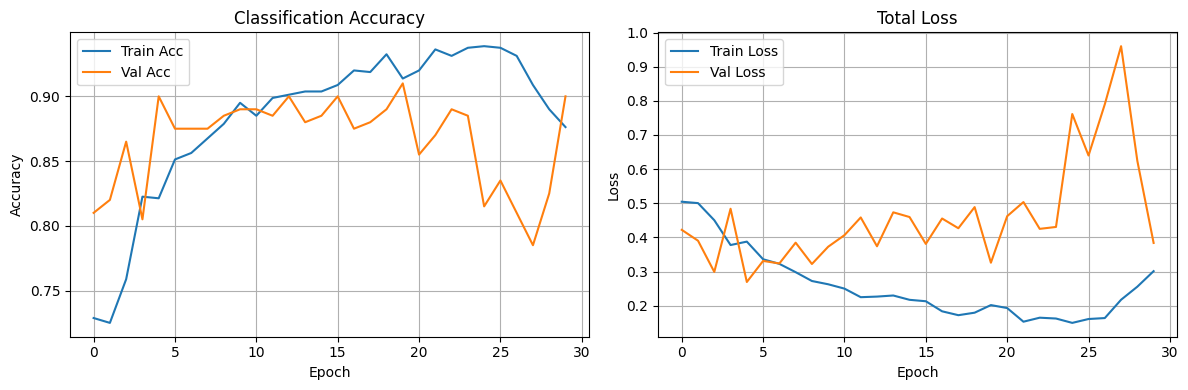

In [93]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['classification_accuracy'], label='Train Acc')
plt.plot(history.history['val_classification_accuracy'], label='Val Acc')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_30epochs.png')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Final θ_E stats:
Mean: 1.437 arcsec
Std: 0.283 arcsec
Min/Max: 0.938 / 2.076 arcsec
Fraction in [0.5–3.0]: 1.000


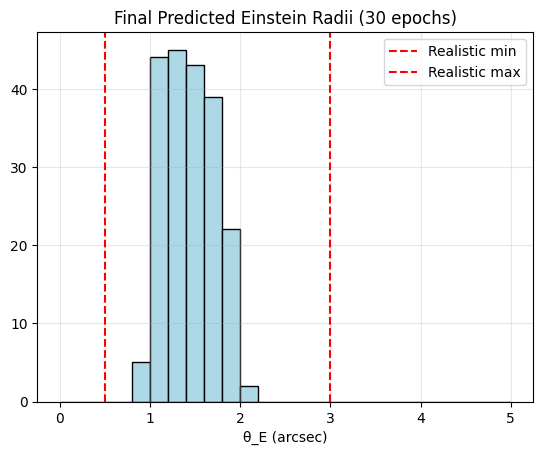

In [95]:
preds = physics_model.predict(X_val)
theta_values = preds[1].flatten()

print("Final θ_E stats:")
print(f"Mean: {np.mean(theta_values):.3f} arcsec")
print(f"Std: {np.std(theta_values):.3f} arcsec")
print(f"Min/Max: {np.min(theta_values):.3f} / {np.max(theta_values):.3f} arcsec")
print(f"Fraction in [0.5–3.0]: {np.mean((theta_values >= 0.5) & (theta_values <= 3.0)):.3f}")

plt.hist(theta_values, bins=25, range=(0,5), color='lightblue', edgecolor='black')
plt.title("Final Predicted Einstein Radii (30 epochs)")
plt.xlabel("θ_E (arcsec)")
plt.axvline(0.5, color='r', ls='--', label='Realistic min')
plt.axvline(3.0, color='r', ls='--', label='Realistic max')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('theta_e_histogram_30epochs.png')
plt.show()

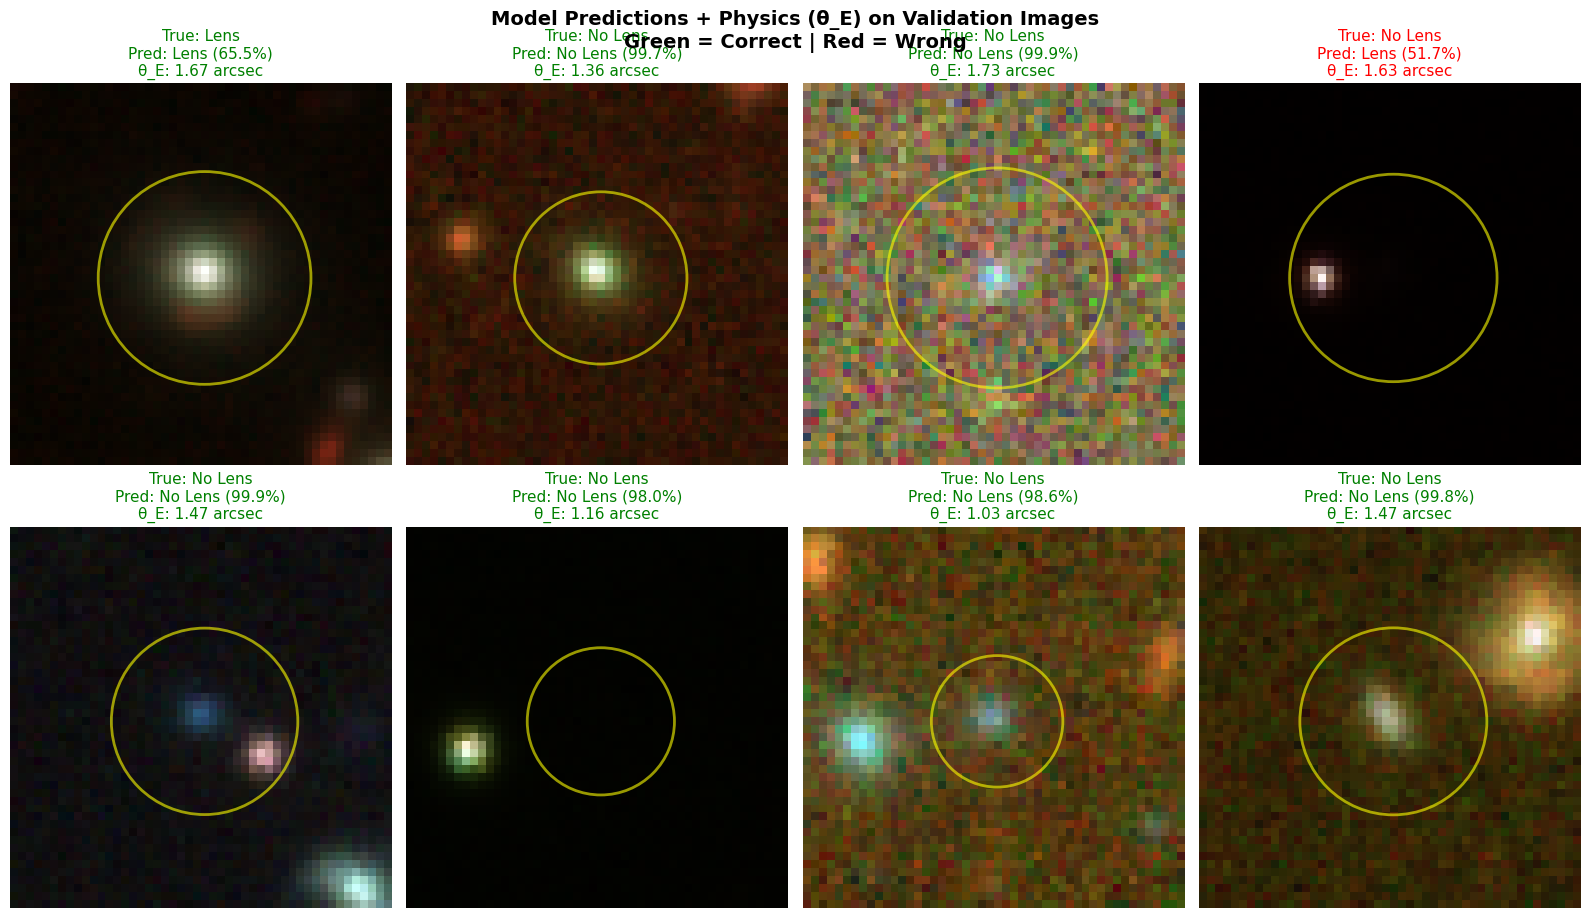

Visualization complete! Yellow circles roughly represent predicted Einstein ring size.


In [ ]:
#     VISUALIZATION: MODEL PREDICTIONS ON VALIDATION IMAGES

import random
import matplotlib.pyplot as plt

# Pick 8 random validation images
indices = random.sample(range(len(X_val)), 8)
sample_images = X_val[indices]
sample_true = y_val[indices]

# Get predictions
preds = physics_model.predict(sample_images, verbose=0)
class_probs = preds[0]
theta_values = preds[1].flatten()

pred_classes = np.argmax(class_probs, axis=1)
confidences = np.max(class_probs, axis=1)

# Plot
plt.figure(figsize=(16, 10))
for i in range(8):
    plt.subplot(2, 4, i+1)
    
    # Show image (handle grayscale/RGB)
    img = sample_images[i]
    if len(img.shape) == 3 and img.shape[-1] == 3:
        plt.imshow(img)
    else:
        plt.imshow(img.squeeze(), cmap='gray')
    
    # Overlay text
    true_class = "Lens" if sample_true[i] == 1 else "No Lens"
    pred_class = "Lens" if pred_classes[i] == 1 else "No Lens"
    
    color = 'green' if pred_classes[i] == sample_true[i] else 'red'
    
    plt.title(f"True: {true_class}\nPred: {pred_class} ({confidences[i]:.1%})\nθ_E: {theta_values[i]:.2f} arcsec", 
              color=color, fontsize=11)
    
    # Add subtle circle for θ_E size (visual hint)
    if theta_values[i] > 0.3:
        circle = plt.Circle((24, 24), theta_values[i]*8, color='yellow', fill=False, linewidth=2, alpha=0.6)
        plt.gca().add_patch(circle)
    
    plt.axis('off')

plt.suptitle("Model Predictions + Physics (θ_E) on Validation Images\nGreen = Correct | Red = Wrong", 
             fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print("Visualization complete! Yellow circles roughly represent predicted Einstein ring size.")

══════════════════════════════════════════════════════════════════════
FINAL EVALUATION — 30 EPOCHS PHYSICS MODEL
══════════════════════════════════════════════════════════════════════
Validation Accuracy     : 90.00%
Weighted F1-Score       : 89.94%
Weighted Precision      : 91.05%
Weighted Recall         : 90.00%
──────────────────────────────────────────────────────────────────────

Per-class Report:
              precision    recall  f1-score   support

     No Lens     0.8448    0.9800    0.9074       100
        Lens     0.9762    0.8200    0.8913       100

    accuracy                         0.9000       200
   macro avg     0.9105    0.9000    0.8994       200
weighted avg     0.9105    0.9000    0.8994       200



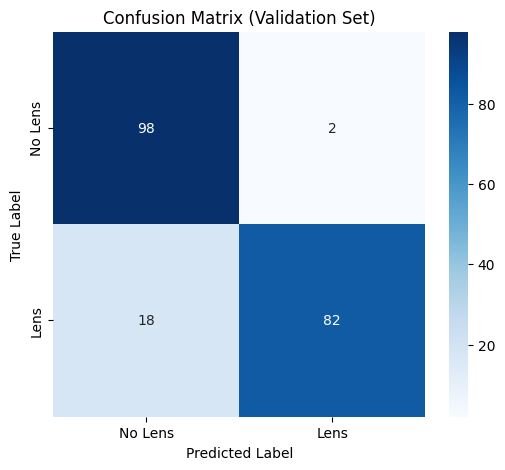


Physics Constraint Evaluation (θ_E):
Mean θ_E      : 1.437 arcsec
Std θ_E       : 0.283 arcsec
Min / Max     : 0.938 / 2.076 arcsec
Fraction in [0.5–3.0] : 100.0% (200 samples)


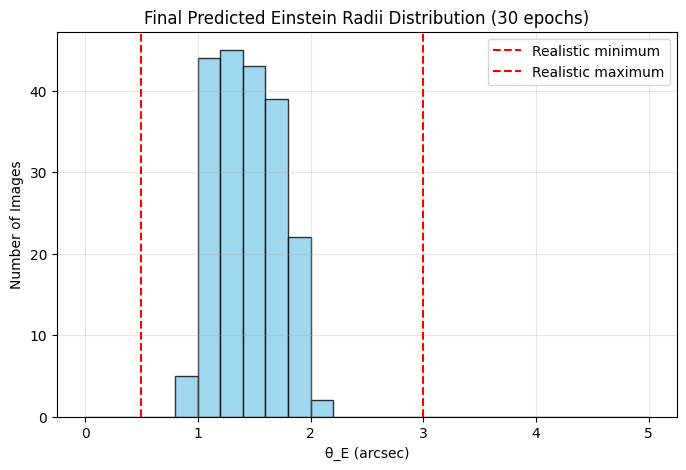

In [ ]:
# EVALUATIO REPORT 

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns

# Final predictions on full validation set
preds = physics_model.predict(X_val, verbose=0)
class_probs = preds[0]
theta_values = preds[1].flatten()

pred_classes = np.argmax(class_probs, axis=1)
true_classes = y_val

# Classification Metrics
acc = np.mean(pred_classes == true_classes)
f1 = f1_score(true_classes, pred_classes, average='weighted')
prec = precision_score(true_classes, pred_classes, average='weighted')
rec = recall_score(true_classes, pred_classes, average='weighted')


print("FINAL EVALUATION — 30 EPOCHS PHYSICS MODEL")
print(f"Validation Accuracy     : {acc*100:.2f}%")
print(f"Weighted F1-Score       : {f1*100:.2f}%")
print(f"Weighted Precision      : {prec*100:.2f}%")
print(f"Weighted Recall         : {rec*100:.2f}%")


print("\nPer-class Report:")
print(classification_report(true_classes, pred_classes, target_names=["No Lens", "Lens"], digits=4))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["No Lens", "Lens"], 
            yticklabels=["No Lens", "Lens"])
plt.title("Confusion Matrix (Validation Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Physics Statistics
print("\nPhysics Constraint Evaluation (θ_E):")
print(f"Mean θ_E      : {np.mean(theta_values):.3f} arcsec")
print(f"Std θ_E       : {np.std(theta_values):.3f} arcsec")
print(f"Min / Max     : {np.min(theta_values):.3f} / {np.max(theta_values):.3f} arcsec")
print(f"Fraction in [0.5–3.0] : {np.mean((theta_values >= 0.5) & (theta_values <= 3.0)):.1%} ({len(theta_values)} samples)")

# Final θ_E Histogram
plt.figure(figsize=(8,5))
plt.hist(theta_values, bins=25, range=(0,5), color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Final Predicted Einstein Radii Distribution (30 epochs)")
plt.xlabel("θ_E (arcsec)")
plt.ylabel("Number of Images")
plt.axvline(0.5, color='red', linestyle='--', label='Realistic minimum')
plt.axvline(3.0, color='red', linestyle='--', label='Realistic maximum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()